# Atividade 2.2 - Linear Regression, p-value and Metrics


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(42)

## Questão A

Gerar dois conjuntos de dados contendo 9 pontos cada, ajustar
uma reta por regressão linear utilizando `linregress` e analisar
o p-value obtido.


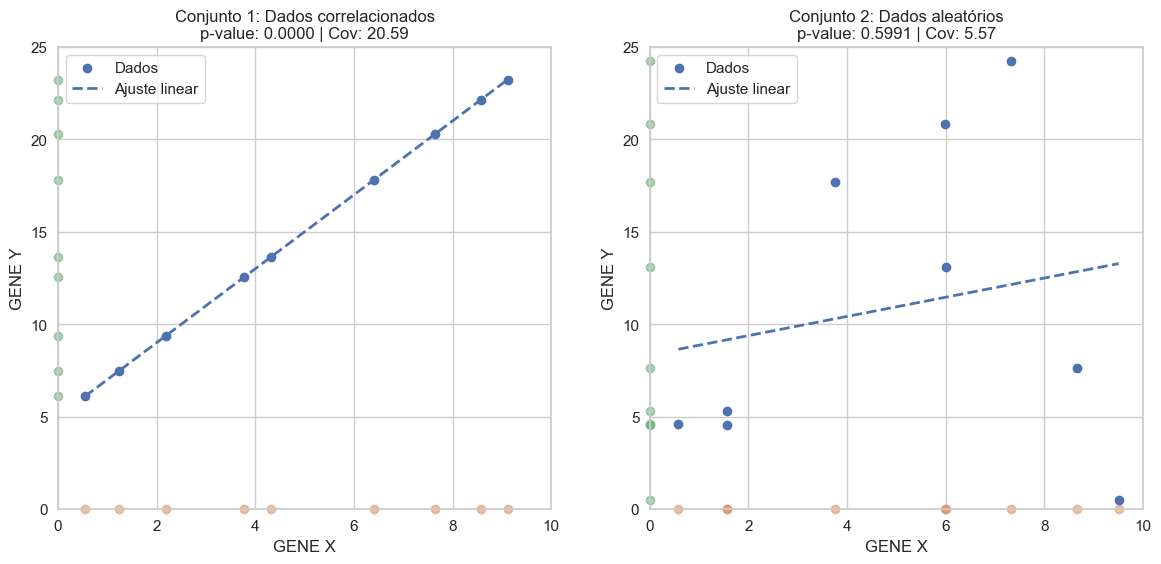

In [43]:
def desenhar(ax, xs, ys, titulo):

    # regressão linear
    ajuste = stats.linregress(xs, ys)

    # covariância
    cov_xy = np.cov(xs, ys)[0, 1]

    # pontos principais
    ax.scatter(xs, ys, zorder=3, label="Dados")

    # projeções nos eixos
    ax.scatter(xs, np.zeros(len(xs)), alpha=0.5, clip_on=False)
    ax.scatter(np.zeros(len(ys)), ys, alpha=0.5, clip_on=False)

    # reta ajustada
    x_linha = np.linspace(min(xs), max(xs), 100)
    y_linha = ajuste.slope * x_linha + ajuste.intercept
    ax.plot(x_linha, y_linha, linestyle="--", linewidth=2, label="Ajuste linear")

    # configuração visual
    ax.set_title(
        f"{titulo}\np-value: {ajuste.pvalue:.4f} | Cov: {cov_xy:.2f}"
    )
    ax.set_xlabel("GENE X")
    ax.set_ylabel("GENE Y")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 25)
    ax.tick_params(direction="inout", length=8, width=2)
    ax.legend()


# ---------- criação da figura ----------
figura, eixos = plt.subplots(1, 2, figsize=(14, 6))

# --------- Conjunto 1 (estrutura linear) ----------
x_linear = [1.24, 8.57, 4.32, 0.55, 9.12, 3.78, 6.41, 2.19, 7.65]
y_linear = [7.48, 22.14, 13.64, 6.10, 23.24, 12.56, 17.82, 9.38, 20.30]

desenhar(eixos[0], x_linear, y_linear, "Conjunto 1: Dados correlacionados")

# --------- Conjunto 2 (aleatório uniforme) ----------
np.random.seed(42)

x_rand = np.random.uniform(0, 10, 9)
y_rand = np.random.uniform(0, 25, 9)

desenhar(eixos[1], x_rand, y_rand, "Conjunto 2: Dados aleatórios")

plt.show()




### Análise do Resultado

No primeiro conjunto, observa-se correlação entre as variáveis,
resultando em p-value baixo e indicando relação linear significativa.

No segundo conjunto, os dados são gerados aleatoriamente,
não apresentando relação clara, o que resulta em p-value maior.

Isso mostra que a regressão linear é adequada quando existe
dependência entre as variáveis.


## Questão B

Nesta etapa utilizamos um conjunto de notas de uma turma como
amostra para estimar o intervalo de confiança da média das
notas da população de estudantes.

Serão calculados intervalos para níveis de confiança de
90%, 95% e 99%, e os resultados serão visualizados em gráfico,
permitindo comparar a variabilidade das estimativas.


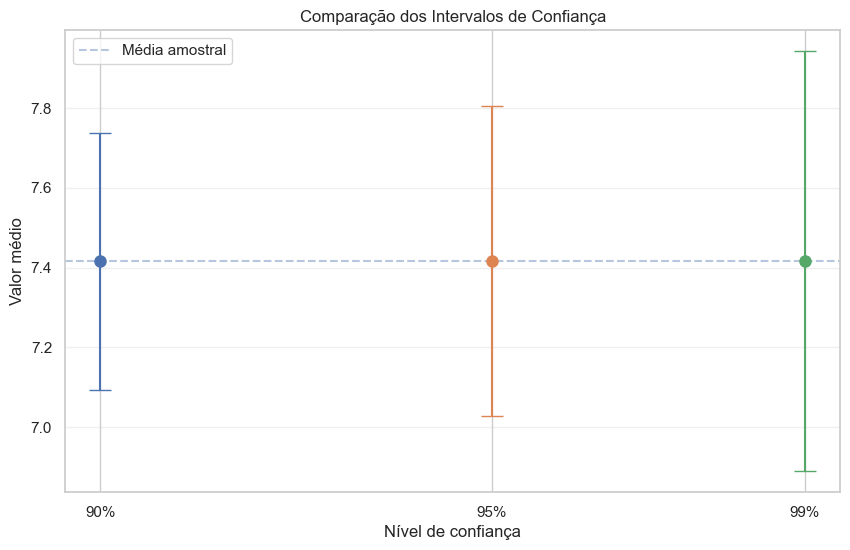

In [61]:
# conjunto de dados: notas de prova
amostra = np.array([
    6.5, 7.0, 8.2, 5.9, 9.1,
    7.8, 6.9, 8.0, 7.3, 6.7,
    8.5, 7.1, 6.4, 9.0, 7.9,
    5.8, 6.2, 8.7, 7.5, 6.8,
    7.4, 8.1, 6.6, 7.7, 8.3
])

# média e desvio padrão amostral
media_amostral = np.mean(amostra)
desvio_amostral = np.std(amostra, ddof=1)

# tamanho da amostra
n = len(amostra)

# níveis de confiança analisados
niveis = [0.90, 0.95, 0.99]
intervalos = []

# cálculo dos intervalos usando distribuição t
for nivel in niveis:
    intervalo = stats.t.interval(
        nivel,
        df=n-1,
        loc=media_amostral,
        scale=stats.sem(amostra)
    )
    intervalos.append(intervalo)

# ---------- gráfico ----------
plt.figure(figsize=(10, 6))

for i, (nivel, intervalo) in enumerate(zip(niveis, intervalos)):
    erro = (intervalo[1] - intervalo[0]) / 2
    plt.errorbar(
        nivel,
        media_amostral,
        yerr=erro,
        fmt="o",
        capsize=8,
        markersize=8
    )

# linha da média
plt.axhline(
    media_amostral,
    linestyle="--",
    alpha=0.4,
    label="Média amostral"
)

plt.title("Comparação dos Intervalos de Confiança")
plt.xlabel("Nível de confiança")
plt.ylabel("Valor médio")
plt.xticks(niveis, ["90%", "95%", "99%"])
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

### Análise do Resultado

Observa-se que o intervalo de confiança aumenta conforme cresce
o nível de confiança adotado.

Isso ocorre porque níveis maiores exigem maior garantia de que a
média real das notas esteja dentro do intervalo estimado,
o que amplia sua largura.

Portanto, existe um compromisso entre precisão da estimativa
e segurança estatística dos resultados.


## Questão C

Nesta etapa comparamos dois grupos independentes: um grupo de
controle e um grupo de teste.

O objetivo é verificar se existe diferença significativa entre as
médias dos grupos utilizando o teste t para duas amostras.


In [60]:
# gerador reprodutível
rng = np.random.default_rng(10)

# grupos simulados
grupo_controle = rng.normal(loc=15.2, scale=2.1, size=30)
grupo_teste = rng.normal(loc=17.5, scale=2.5, size=30)

# médias dos grupos
media_controle = np.mean(grupo_controle)
media_teste = np.mean(grupo_teste)

print(f"Média controle: {media_controle:.2f}")
print(f"Média teste: {media_teste:.2f}")

# teste t para duas amostras independentes
estatistica_t, p_valor = stats.ttest_ind(grupo_controle, grupo_teste)

print(f"Estatística t: {estatistica_t:.6f}")
print(f"p-value: {p_valor:.6f}")

Média controle: 14.63
Média teste: 17.08
Estatística t: -4.927991
p-value: 0.000007


### Formulação das Hipóteses

Hipótese nula (H0):
Não existe diferença entre as médias dos grupos.

Hipótese alternativa (H1):
Existe diferença entre as médias dos grupos.


### Análise do Resultado

Adotando nível de significância de 5% (α = 0,05):

O p-value obtido é muito menor que 0,05, indicando que a
probabilidade de a diferença observada ocorrer apenas por acaso é
extremamente pequena.

Assim, rejeitamos a hipótese nula.


### Conclusão

Os resultados indicam que o grupo de teste apresenta média superior
ao grupo de controle, e essa diferença é estatisticamente
significativa.

Portanto, há evidência de que o tratamento ou condição aplicada ao
grupo de teste produziu efeito real.


In [65]:
num_simulations = 10000
sample_size = 30
true_mean = 50
true_std = 10
significance_level = 0.01#Usar valores diferentes


significant_results = 0


for _ in range(num_simulations):

    group1 = np.random.normal(true_mean, true_std, sample_size)
    group2 = np.random.normal(true_mean, true_std, sample_size)


    t_stat, p_value = ttest_ind(group1, group2)

    if p_value < significance_level:
        significant_results += 1


proportion_significant = significant_results / num_simulations


print(f"Number of simulations: {num_simulations}")
print(f"Significance level (alpha): {significance_level}")
print(f"Proportion of significant results (Type I error rate): {proportion_significant:.4f}")

Number of simulations: 10000
Significance level (alpha): 0.01
Proportion of significant results (Type I error rate): 0.0097


## Questão D

Link para o slide: https://docs.google.com/presentation/d/1909FrChYkWbw2WCJagJg6buiYYTPxxOAGq8TBydLPS8/edit?usp=sharing

## Questão E

Intervalo para média:
Margem de erro: 3.80
Intervalo: [72.1, 79.7]

Intervalo para proporção:
Margem de erro: 0.090
Intervalo: [0.030, 0.210]


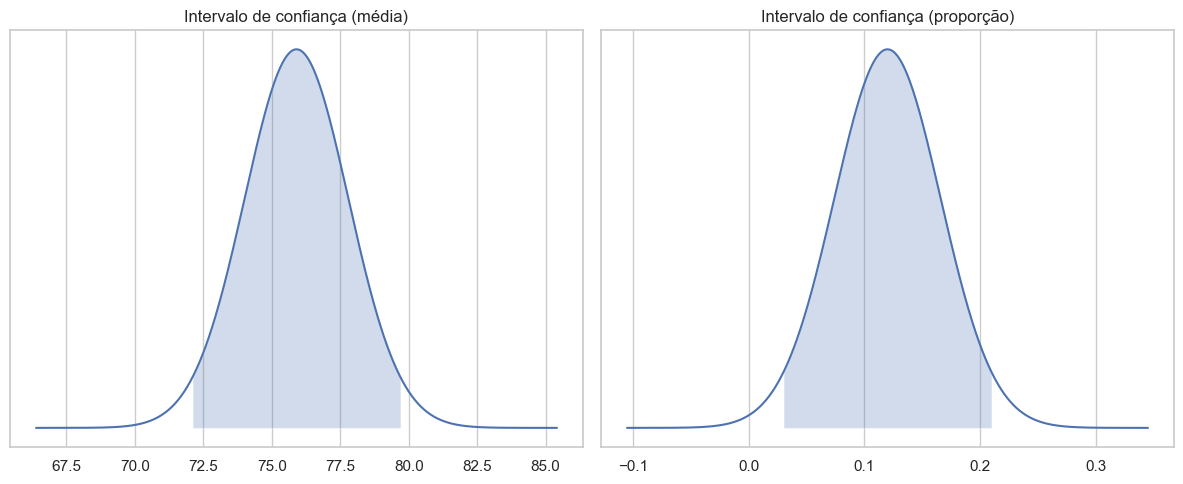

In [56]:
# ---------------------------
# 1) Dados do problema
# ---------------------------
n = 50                # tamanho da amostra
df = n - 1            # graus de liberdade
confidence = 0.975    # para intervalo de 95%

# média e desvio padrão amostral
media = 75.9
desvio = 13.3854

# proporção observada
proporcao = 0.120


# ---------------------------
# 2) Intervalo para a média
# ---------------------------

# erro padrão da média
erro_padrao_media = desvio / math.sqrt(n)

# valor crítico t
t_critico = stats.t.ppf(confidence, df)

# margem de erro
erro_media = t_critico * erro_padrao_media

# intervalo
media_inf = media - erro_media
media_sup = media + erro_media


# ---------------------------
# 3) Intervalo para proporção
# ---------------------------

# erro padrão da proporção
erro_padrao_prop = math.sqrt((proporcao * (1 - proporcao)) / n)

# valor crítico z
z_critico = stats.norm.ppf(confidence)

# margem de erro
erro_prop = z_critico * erro_padrao_prop

# intervalo
prop_inf = proporcao - erro_prop
prop_sup = proporcao + erro_prop


# ---------------------------
# 4) Resultados numéricos
# ---------------------------

print("Intervalo para média:")
print(f"Margem de erro: {erro_media:.2f}")
print(f"Intervalo: [{media_inf:.1f}, {media_sup:.1f}]\n")

print("Intervalo para proporção:")
print(f"Margem de erro: {erro_prop:.3f}")
print(f"Intervalo: [{prop_inf:.3f}, {prop_sup:.3f}]")


# ---------------------------
# 5) Visualização gráfica
# ---------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ---- Média ----
x_m = np.linspace(media - 2.5*erro_media,
                  media + 2.5*erro_media, 500)

y_m = stats.norm.pdf(x_m, media, erro_padrao_media)

ax1.plot(x_m, y_m)
ax1.fill_between(
    x_m, y_m,
    where=((x_m >= media_inf) & (x_m <= media_sup)),
    alpha=0.25
)

ax1.set_title("Intervalo de confiança (média)")
ax1.set_yticks([])

# ---- Proporção ----
x_p = np.linspace(proporcao - 2.5*erro_prop,
                  proporcao + 2.5*erro_prop, 500)

y_p = stats.norm.pdf(x_p, proporcao, erro_padrao_prop)

ax2.plot(x_p, y_p)
ax2.fill_between(
    x_p, y_p,
    where=((x_p >= prop_inf) & (x_p <= prop_sup)),
    alpha=0.25
)

ax2.set_title("Intervalo de confiança (proporção)")
ax2.set_yticks([])

plt.tight_layout()
plt.show()


## Questão F

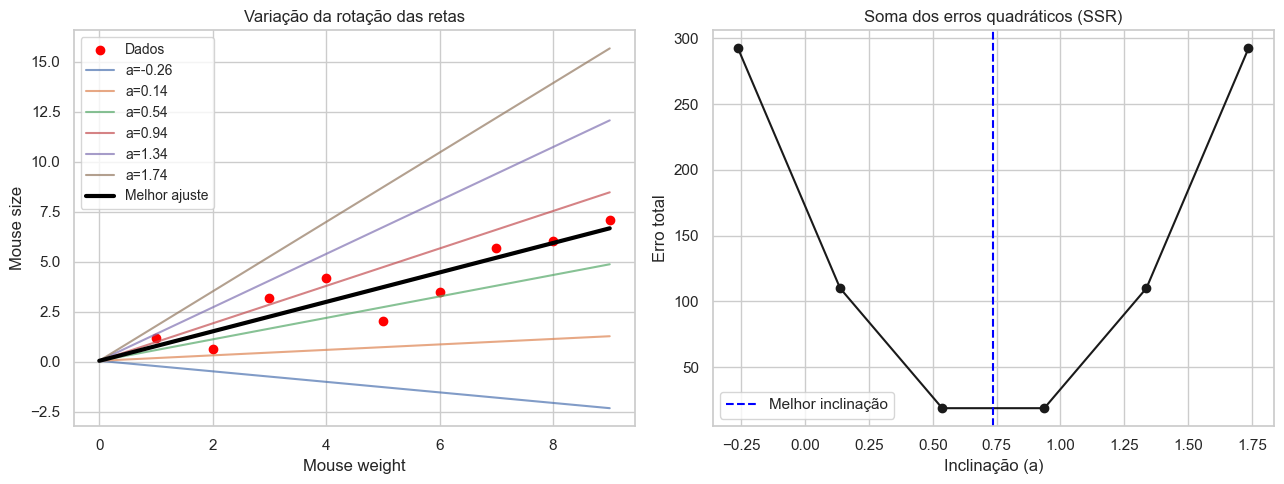

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     30.66
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           0.000871
Time:                        23:11:26   Log-Likelihood:                -11.909
No. Observations:                   9   AIC:                             27.82
Df Residuals:                       7   BIC:                             28.21
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0388      0.749      0.052      0.9

In [48]:
from sklearn.metrics import r2_score

# ---------------------------------------------------
# 1) DATA — (peso x tamanho)
# ---------------------------------------------------
rng = np.random.default_rng(42)

x = np.array([1,2,3,4,5,6,7,8,9]).reshape(-1,1)
y = 0.1 + 0.78*x.flatten() + rng.normal(0,1.0,len(x))

# ---------------------------------------------------
# 2) REGRESSÃO COM SCIKIT-LEARN
# ---------------------------------------------------
model = LinearRegression().fit(x, y)

ideal_a = model.coef_[0]       # slope
ideal_b = model.intercept_     # intercept

# ---------------------------------------------------
# 3) ESTATÍSTICAS COM STATSMODELS
# ---------------------------------------------------
x_const = sm.add_constant(x)
report = sm.OLS(y, x_const).fit()

# ---------------------------------------------------
# 4) TESTE DE DIFERENTES ROTAÇÕES (valores de a)
# ---------------------------------------------------
slopes = np.linspace(ideal_a - 1, ideal_a + 1, 6)

ssr_list = []
r2_list = []

plt.figure(figsize=(13,5))

# ---------- GRÁFICO 1: RETAS ROTACIONADAS ----------
plt.subplot(1,2,1)

plt.scatter(x, y, color='red', label='Dados')

x_plot = np.linspace(0, 9, 100)

for a in slopes:
    y_line = ideal_b + a*x_plot
    plt.plot(x_plot, y_line, alpha=0.7, label=f"a={a:.2f}")
    
    y_calc = ideal_b + a*x.flatten()
    
    ssr = np.sum((y - y_calc)**2)
    ssr_list.append(ssr)
    
    r2_list.append(r2_score(y, y_calc))

plt.plot(x_plot,
         ideal_b + ideal_a*x_plot,
         color='black',
         linewidth=3,
         label="Melhor ajuste")

plt.title("Variação da rotação das retas")
plt.xlabel("Mouse weight")
plt.ylabel("Mouse size")
plt.legend(fontsize="small")

# ---------- GRÁFICO 2: Soma dos erros ----------
plt.subplot(1,2,2)

plt.plot(slopes, ssr_list, 'o-k')
plt.axvline(ideal_a,
            color='blue',
            linestyle='--',
            label="Melhor inclinação")

plt.title("Soma dos erros quadráticos (SSR)")
plt.xlabel("Inclinação (a)")
plt.ylabel("Erro total")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 5) RESULTADOS ESTATÍSTICOS
# ---------------------------------------------------
print(report.summary())

print("\n===== ANÁLISE DO MODELO IDEAL =====")
print(f"R-squared:          {report.rsquared:.4f}")
print(f"Adj R-squared:      {report.rsquared_adj:.4f}")
print(f"F-statistic:        {report.fvalue:.4f}")
print(f"Prob(F-statistic):  {report.f_pvalue:.4e}")
print(f"P-value da inclinação: {report.pvalues[1]:.4e}")

# ---------------------------------------------------
# 6) Comparação entre rotações
# ---------------------------------------------------
print("\n===== COMPARAÇÃO ENTRE INCLINAÇÕES =====")
print(f"{'a testado':<15} | {'R²':<10} | Status")
print("-"*45)

for i, a in enumerate(slopes):
    
    if abs(a - ideal_a) < 0.1:
        status = "Próximo do ideal"
    else:
        status = "Pior ajuste"
    
    print(f"{a:<15.4f} | {r2_list[i]:<10.4f} | {status}")

print("-"*45)
print(f"{ideal_a:<15.4f} | {report.rsquared:<10.4f} | Melhor modelo")

## Análise da Regressão Linear

Aplicamos regressão linear para modelar a relação entre as variáveis simuladas, buscando a reta que melhor se ajusta aos dados pelo método dos mínimos quadrados.

### R-squared (R²)
O R² indica quanto da variação dos dados é explicada pelo modelo. Valores próximos de 1 mostram um bom ajuste da reta aos pontos.

### Adjusted R-squared
É uma versão ajustada do R² que penaliza modelos excessivamente complexos. Como usamos apenas uma variável explicativa, ele permanece muito próximo do R².

### F-statistic e Prob(F-statistic)
A estatística F avalia se o modelo é significativo como um todo. A probabilidade associada (Prob(F)) indica a chance do resultado ocorrer ao acaso; valores menores que 0.05 mostram que o modelo é estatisticamente válido.

### P-value da inclinação
O p-value associado ao coeficiente angular indica se existe relação significativa entre as variáveis. Valores menores que 0.05 confirmam que a inclinação é relevante.

### Variação das retas (valores de *a*)
Ao testar diferentes inclinações (*a*), observa-se que a soma dos erros quadráticos aumenta quando a reta se afasta do melhor ajuste. O modelo do scikit-learn corresponde ao menor erro e maior R².

### Conclusão
Os resultados mostram que a regressão linear descreve adequadamente os dados, e que pequenas mudanças na inclinação aumentam o erro, confirmando a existência de uma inclinação ótima para o ajuste.


## Questão G

In [49]:
def lu_fatoracao(A, b):
    A = A.astype(float)
    b = b.astype(float)
    n = len(A)

    # vetor de permutação
    p = np.arange(n)

    print("\nMatriz inicial A:")
    print(A, "\n")

    # --- Fatoração LU ---
    for k in range(n - 1):

        # escolha do pivô
        r = np.argmax(np.abs(A[k:, k])) + k

        if A[r, k] == 0:
            raise ValueError("Matriz singular.")

        # troca de linhas
        if r != k:
            A[[k, r]] = A[[r, k]]
            p[[k, r]] = p[[r, k]]

            print(f"Iteração {k+1}: troca das linhas {k+1} e {r+1}")
            print(A, "\n")

        # eliminação
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k] = m

            for j in range(k + 1, n):
                A[i, j] -= m * A[k, j]

        print(f"Após eliminar coluna {k+1}:")
        print(A, "\n")

    # --- Permutação do vetor b ---
    c = b[p]
    print("Vetor c = Pb:", c, "\n")

    # --- Substituição direta (Ly = c) ---
    y = np.zeros(n)
    for i in range(n):
        y[i] = c[i] - np.dot(A[i, :i], y[:i])

    print("Vetor y:", y, "\n")

    # --- Substituição retroativa (Ux = y) ---
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.dot(A[i, i+1:], x[i+1:])) / A[i, i]

    return x


# ===== Exemplo 7 do livro =====
A = np.array([
    [3, -4,  1],
    [1,  2,  2],
    [4,  0, -3]
])

b = np.array([9, 3, -2])

x = lu_fatoracao(A, b)

print("Solução final:", x)


Matriz inicial A:
[[ 3. -4.  1.]
 [ 1.  2.  2.]
 [ 4.  0. -3.]] 

Iteração 1: troca das linhas 1 e 3
[[ 4.  0. -3.]
 [ 1.  2.  2.]
 [ 3. -4.  1.]] 

Após eliminar coluna 1:
[[ 4.    0.   -3.  ]
 [ 0.25  2.    2.75]
 [ 0.75 -4.    3.25]] 

Iteração 2: troca das linhas 2 e 3
[[ 4.    0.   -3.  ]
 [ 0.75 -4.    3.25]
 [ 0.25  2.    2.75]] 

Após eliminar coluna 2:
[[ 4.     0.    -3.   ]
 [ 0.75  -4.     3.25 ]
 [ 0.25  -0.5    4.375]] 

Vetor c = Pb: [-2.  9.  3.] 

Vetor y: [-2.   10.5   8.75] 

Solução final: [ 1. -1.  2.]


## Questão G

In [50]:
def jacobi_teorema4(A, b, x0, eps, max_iter=100):

    A = A.astype(float)
    b = b.astype(float)
    x_old = x0.astype(float)

    n = len(A)

    print("\nSistema Ax = b")
    print("A =\n", A)
    print("b =", b)
    print("\nVetor inicial:", x_old, "\n")

    # -------- Teorema 4 --------
    print("Verificando condição de convergência:")

    alphas = []
    for i in range(n):
        soma = np.sum(np.abs(A[i, :])) - abs(A[i, i])
        alpha_i = soma / abs(A[i, i])
        alphas.append(alpha_i)

    max_alpha = max(alphas)

    print("Alphas =", alphas)
    print("Máximo alpha =", max_alpha)

    if max_alpha < 1:
        print("→ Convergência garantida.\n")
    else:
        print("→ Convergência não garantida.\n")

    # -------- Iterações --------
    for k in range(1, max_iter + 1):

        x_new = np.zeros(n)

        for i in range(n):
            soma = (
                np.dot(A[i, :i], x_old[:i]) +
                np.dot(A[i, i+1:], x_old[i+1:])
            )

            x_new[i] = (b[i] - soma) / A[i, i]

        erro = np.max(np.abs(x_new - x_old))
        dr = erro / np.max(np.abs(x_new))

        print(f"Iteração {k}")
        print("x =", x_new)
        print("dr =", dr, "\n")

        if dr < eps:
            print("Convergência atingida.")
            return x_new

        x_old = x_new.copy()

    return x_old

In [51]:
A = np.array([
    [10, 2, 1],
    [1, 5, 1],
    [2, 3, 10]
])

b = np.array([7, -8, 6])

x0 = np.array([0.7, -1.6, 0.6])

epsilon = 0.05

solucao = jacobi_teorema4(A, b, x0, epsilon)

print("\nSolução aproximada:", solucao)



Sistema Ax = b
A =
 [[10.  2.  1.]
 [ 1.  5.  1.]
 [ 2.  3. 10.]]
b = [ 7. -8.  6.]

Vetor inicial: [ 0.7 -1.6  0.6] 

Verificando condição de convergência:
Alphas = [np.float64(0.3), np.float64(0.4), np.float64(0.5)]
Máximo alpha = 0.5
→ Convergência garantida.

Iteração 1
x = [ 0.96 -1.86  0.94]
dr = 0.18279569892473121 

Iteração 2
x = [ 0.978 -1.98   0.966]
dr = 0.060606060606060545 

Iteração 3
x = [ 0.9994 -1.9888  0.9984]
dr = 0.016291230893000743 

Convergência atingida.

Solução aproximada: [ 0.9994 -1.9888  0.9984]


## Questão I

### 1) Critério de Sassenfeld

O critério de Sassenfeld garante a convergência do método de Gauss-Seidel se:

max(βᵢ) < 1

Os valores βᵢ são calculados progressivamente usando os coeficientes da matriz.


In [52]:
def criterio_sassenfeld(A):
    n = len(A)
    betas = np.zeros(n)

    for i in range(n):
        soma1 = np.sum(np.abs(A[i, :i]) * betas[:i])
        soma2 = np.sum(np.abs(A[i, i+1:]))

        betas[i] = (soma1 + soma2) / abs(A[i, i])

    print("Betas:", betas)
    print("Max beta:", np.max(betas))

    if np.max(betas) < 1:
        print("Convergência garantida pelo critério de Sassenfeld.\n")
    else:
        print("Convergência não garantida.\n")

    return betas

### 2) Critério das Linhas

O sistema converge se a matriz for diagonalmente dominante:

|aᵢᵢ| > soma dos demais elementos da linha.

Isso é verificado para todas as linhas da matriz.


In [53]:
def criterio_linhas(A):
    n = len(A)
    dominante = True

    for i in range(n):
        soma = np.sum(np.abs(A[i, :])) - abs(A[i, i])
        print(f"Linha {i+1}: |a_ii| = {abs(A[i,i])}, soma = {soma}")

        if abs(A[i, i]) <= soma:
            dominante = False

    if dominante:
        print("Matriz diagonalmente dominante → convergência garantida.\n")
    else:
        print("Sem garantia pelo critério das linhas.\n")

    return dominante

### 3) Método de Gauss-Seidel

O método atualiza os valores do vetor solução a cada iteração,
utilizando imediatamente os valores recém-calculados.

O processo continua até que o erro relativo fique abaixo da tolerância definida.


In [54]:
def gauss_seidel(A, b, x0, eps, max_iter=100):
    n = len(A)

    A = A.astype(float)
    b = b.astype(float)

    x = x0.astype(float)

    for k in range(1, max_iter + 1):
        x_old = x.copy()

        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])
            soma2 = np.dot(A[i, i+1:], x_old[i+1:])

            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        erro = np.max(np.abs(x - x_old))
        dr = erro / np.max(np.abs(x))

        print(f"Iteração {k}")
        print("x =", x)
        print("dr =", dr, "\n")

        if dr < eps:
            print("Convergência atingida.\n")
            return x

    return x


### 4) Aplicação — Exemplo 14 do livro

Sistema resolvido:

5x + y + z = 5  
3x + 4y + z = 6  
3x + 3y + 6z = 0

Usamos vetor inicial nulo e tolerância de erro 0.05.


In [55]:
A = np.array([
    [5, 1, 1],
    [3, 4, 1],
    [3, 3, 6]
])

b = np.array([5, 6, 0])

x0 = np.array([0, 0, 0])
eps = 0.05

print("=== Critério de Sassenfeld ===")
criterio_sassenfeld(A)

print("=== Critério das Linhas ===")
criterio_linhas(A)

print("=== Gauss-Seidel ===")
solucao = gauss_seidel(A, b, x0, eps)

print("Solução aproximada:", solucao)


=== Critério de Sassenfeld ===
Betas: [0.4   0.55  0.475]
Max beta: 0.55
Convergência garantida pelo critério de Sassenfeld.

=== Critério das Linhas ===
Linha 1: |a_ii| = 5, soma = 2
Linha 2: |a_ii| = 4, soma = 4
Linha 3: |a_ii| = 6, soma = 6
Sem garantia pelo critério das linhas.

=== Gauss-Seidel ===
Iteração 1
x = [ 1.     0.75  -0.875]
dr = 1.0 

Iteração 2
x = [ 1.025   0.95   -0.9875]
dr = 0.19512195121951229 

Iteração 3
x = [ 1.0075    0.99125  -0.999375]
dr = 0.04094292803970225 

Convergência atingida.

Solução aproximada: [ 1.0075    0.99125  -0.999375]


### 5) Conclusão

Ambos os critérios indicam convergência do método.
O método de Gauss-Seidel converge rapidamente,
obtendo solução próxima de:

x ≈ (1, 1, -1)

em poucas iterações.
